# Assignment 3: Hybrid Semantic Retrieval & Intelligence System (HSRIS)
## NLP Pipeline for Customer Support Ticket Processing
**Team:** Abdul Mujeeb(23F-6043), Ahmad Mujtaba(23F-3053)  
**Platform:** Kaggle with Dual T4 x2 GPU  
**Dataset:** Customer Support Ticket Dataset (~8,470 records)

---
## CELL 1: Install Dependencies

In [16]:
# Install required libraries
!pip install gradio --quiet
!pip install kaggle --quiet

# Download GloVe embeddings (300d)
import os
if not os.path.exists('/kaggle/working/glove.6B.300d.txt'):
    !wget -q http://nlp.stanford.edu/data/glove.6B.zip -O /kaggle/working/glove.6B.zip
    !unzip -q /kaggle/working/glove.6B.zip -d /kaggle/working/
    print('GloVe downloaded and extracted.')
else:
    print('GloVe already exists.')

GloVe downloaded and extracted.


---
## CELL 2: Import All Libraries

In [2]:
import os
import re
import math
import time
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F

# Seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device configuration
if torch.cuda.is_available():
    device = torch.device('cuda')
    n_gpus = torch.cuda.device_count()
    print(f'GPUs available: {n_gpus}')
    for i in range(n_gpus):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')
else:
    device = torch.device('cpu')
    n_gpus = 0
    print('No GPU found, using CPU.')

print(f'Using device: {device}')

GPUs available: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Using device: cuda


---
## CELL 3: Load the Dataset

In [5]:
# ------------------------------------------------------------------
# Load the Customer Support Ticket Dataset from Kaggle input
# The dataset is available at:
# https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset
# On Kaggle, datasets are auto-mounted at /kaggle/input/
# ------------------------------------------------------------------

# Try common Kaggle input paths
possible_paths = [
    '/kaggle/input/datasets/suraj520/customer-support-ticket-dataset/customer_support_tickets.csv',
    '/kaggle/input/customer-support-ticket-dataset/customer_support_tickets.csv',
    '/kaggle/input/customer-support-tickets/customer_support_tickets.csv',
]

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f'Dataset loaded from: {path}')
        break

if df is None:
    # List available input directories to help user find the correct path
    print('Dataset not found. Available input files:')
    for root, dirs, files in os.walk('/kaggle/input'):
        for f in files:
            print(os.path.join(root, f))
    raise FileNotFoundError('Please update the path above to match your dataset location.')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Dataset loaded from: /kaggle/input/datasets/suraj520/customer-support-ticket-dataset/customer_support_tickets.csv
Shape: (8469, 17)
Columns: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


---
## CELL 4: Data Exploration & Cleaning

In [7]:
# ------------------------------------------------------------------
# Explore and clean the dataset
# Focus fields: Ticket Description, Ticket Subject,
#               Ticket Priority, Ticket Type, Ticket Channel
# ------------------------------------------------------------------

print('=== Dataset Info ===')
print(df.info())
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()

# Rename columns for convenience (strip spaces, lowercase)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print('Renamed columns:', list(df.columns))

# Identify the exact column names
# Typical names in this dataset:
# 'ticket_description', 'ticket_subject', 'ticket_priority',
# 'ticket_type', 'ticket_channel'

# Map to standardized names
col_map = {}
for col in df.columns:
    if 'description' in col:  col_map[col] = 'ticket_description'
    elif 'subject'     in col:  col_map[col] = 'ticket_subject'
    elif 'priority'    in col:  col_map[col] = 'ticket_priority'
    elif 'type'        in col:  col_map[col] = 'ticket_type'
    elif 'channel'     in col:  col_map[col] = 'ticket_channel'

df.rename(columns=col_map, inplace=True)
print('Standardized column names:', [c for c in col_map.values() if c in df.columns])

FOCUS_COLS = ['ticket_description', 'ticket_subject',
              'ticket_priority', 'ticket_type', 'ticket_channel']

# Keep only rows where all focus columns are non-null
df_clean = df[FOCUS_COLS].dropna().reset_index(drop=True)
print(f'Records after dropping nulls: {len(df_clean)}')

# Value counts for categorical fields
for col in ['ticket_priority', 'ticket_type', 'ticket_channel']:
    print(f'\n{col} value counts:')
    print(df_clean[col].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ticket_id                     8469 non-null   int64  
 1   customer_name                 8469 non-null   object 
 2   customer_email                8469 non-null   object 
 3   customer_age                  8469 non-null   int64  
 4   customer_gender               8469 non-null   object 
 5   product_purchased             8469 non-null   object 
 6   date_of_purchase              8469 non-null   object 
 7   ticket_type                   8469 non-null   object 
 8   ticket_subject                8469 non-null   object 
 9   ticket_description            8469 non-null   object 
 10  ticket_status                 8469 non-null   object 
 11  resolution                    2769 non-null   object 
 12  ticket_priority               8469 non-nu

---
## CELL 5: Part 1 — Label Encoding (Ticket Priority)

In [9]:
# ==================================================================
# PART 1: CATEGORICAL FOUNDATION — THE ENCODERS
# ==================================================================
# ---- 1A: Label Encoding (from scratch, NO sklearn) ---------------

class LabelEncoderCustom:
    """
    Custom Label Encoder built from first principles.
    Maps categorical string values to integer indices.
    """
    def __init__(self, ordered_classes: Optional[List[str]] = None):
        """
        Parameters
        ----------
        ordered_classes : list, optional
            If provided, these classes are mapped in the given order
            (useful for ordinal encoding, e.g., Low=0, Medium=1, High=2).
        """
        self.ordered_classes = ordered_classes
        self.class_to_idx: Dict[str, int] = {}
        self.idx_to_class: Dict[int, str] = {}
        self.is_fitted = False

    def fit(self, labels: List[str]) -> 'LabelEncoderCustom':
        if self.ordered_classes:
            classes = self.ordered_classes
        else:
            classes = sorted(set(labels))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
        self.idx_to_class = {idx: cls for cls, idx in self.class_to_idx.items()}
        self.is_fitted = True
        return self

    def transform(self, labels: List[str]) -> np.ndarray:
        if not self.is_fitted:
            raise RuntimeError('Encoder not fitted. Call fit() first.')
        encoded = []
        for lbl in labels:
            if lbl in self.class_to_idx:
                encoded.append(self.class_to_idx[lbl])
            else:
                # Unseen category: map to -1 (sentinel for unknown)
                encoded.append(-1)
                print(f'  [LabelEncoder] WARNING: unseen label "{lbl}" mapped to -1')
        return np.array(encoded, dtype=np.int64)

    def fit_transform(self, labels: List[str]) -> np.ndarray:
        return self.fit(labels).transform(labels)

    def inverse_transform(self, indices: List[int]) -> List[str]:
        return [self.idx_to_class.get(i, '<UNKNOWN>') for i in indices]


# Ordinal mapping: Low < Medium < High (standard ticket priority ordering)
priority_encoder = LabelEncoderCustom(ordered_classes=['Low', 'Medium', 'High', 'Critical'])
priority_encoded = priority_encoder.fit_transform(df_clean['ticket_priority'].tolist())

print('Priority Encoding Map:', priority_encoder.class_to_idx)
print('Sample encodings (first 10):', priority_encoded[:10])
print('Inverse check:', priority_encoder.inverse_transform(priority_encoded[:5].tolist()))

Priority Encoding Map: {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
Sample encodings (first 10): [3 3 0 0 0 0 3 3 0 3]
Inverse check: ['Critical', 'Critical', 'Low', 'Low', 'Low']


---
## CELL 6: Part 1 — One-Hot Encoding (Ticket Channel)

In [10]:
# ---- 1B: One-Hot Encoding (from scratch, NO sklearn) -------------

class OneHotEncoderCustom:
    """
    Custom One-Hot Encoder built from first principles.
    Converts categorical values into binary vector representations.
    Handles unseen categories during inference using a zero vector.
    """
    def __init__(self):
        self.categories: List[str] = []
        self.cat_to_idx: Dict[str, int] = {}
        self.is_fitted = False

    def fit(self, values: List[str]) -> 'OneHotEncoderCustom':
        self.categories = sorted(set(values))
        self.cat_to_idx  = {cat: idx for idx, cat in enumerate(self.categories)}
        self.is_fitted = True
        return self

    def transform(self, values: List[str]) -> np.ndarray:
        """
        Returns a 2-D NumPy array of shape (N, n_categories).
        Unseen categories → all-zero vector (silent fallback, no crash).
        """
        if not self.is_fitted:
            raise RuntimeError('Encoder not fitted. Call fit() first.')
        n = len(values)
        k = len(self.categories)
        matrix = np.zeros((n, k), dtype=np.float32)
        for row, val in enumerate(values):
            if val in self.cat_to_idx:
                matrix[row, self.cat_to_idx[val]] = 1.0
            else:
                # Unseen during inference → zero vector (default mapping)
                print(f'  [OneHotEncoder] WARNING: unseen category "{val}" → zero vector')
        return matrix

    def fit_transform(self, values: List[str]) -> np.ndarray:
        return self.fit(values).transform(values)

    def decode(self, vector: np.ndarray) -> str:
        """Decode a single one-hot vector back to its category string."""
        idx = int(np.argmax(vector))
        if vector[idx] == 0:
            return '<UNKNOWN>'
        return self.categories[idx]


channel_encoder = OneHotEncoderCustom()
channel_encoded = channel_encoder.fit_transform(df_clean['ticket_channel'].tolist())

print('Channel categories:', channel_encoder.categories)
print(f'One-hot matrix shape: {channel_encoded.shape}')
print('Sample row (index 0):',  channel_encoded[0])
print('Decoded back:', channel_encoder.decode(channel_encoded[0]))

# Test unseen-category handling
print('\nUnseen category test:')
test_vec = channel_encoder.transform(['FaxMachine'])[0]
print('  Result for unseen "FaxMachine":', test_vec)

Channel categories: ['Chat', 'Email', 'Phone', 'Social media']
One-hot matrix shape: (8469, 4)
Sample row (index 0): [0. 0. 0. 1.]
Decoded back: Social media

Unseen category test:
  [OneHotEncoder] WARNING: unseen category "FaxMachine" → zero vector
  Result for unseen "FaxMachine": [0. 0. 0. 0.]


---
## CELL 7: Part 2 — Custom Tokenizer

In [11]:
# ==================================================================
# PART 2: SPARSE REPRESENTATION — KEYWORD RETRIEVAL
# ==================================================================
# ---- 2A: Custom Regex-Based Tokenizer ----------------------------

# Basic English stop-words to filter out extremely common words
STOP_WORDS = set([
    'a','an','the','and','or','but','in','on','at','to','for','of','with',
    'by','from','is','was','are','were','be','been','being','have','has',
    'had','do','does','did','will','would','could','should','may','might',
    'shall','can','need','dare','ought','used','this','that','these','those',
    'it','its','i','me','my','we','our','you','your','he','his','she','her',
    'they','their','them','what','which','who','whom','not','no','nor','so',
    'yet','both','either','neither','each','all','any','much','more','most',
    'other','some','such','only','same','than','too','very','just','about',
    'also','as','if','then','there','here','when','where','how','why','up',
    'out','into','through','during','before','after','above','below','between',
])


def tokenize(text: str,
             remove_stopwords: bool = True,
             min_token_len: int = 2) -> List[str]:
    """
    Custom regex-based tokenizer.

    Steps:
      1. Lowercase the text.
      2. Remove non-alphabetic characters (keep spaces).
      3. Split on whitespace.
      4. Optionally remove stop-words and very short tokens.

    Returns a list of token strings.
    """
    if not isinstance(text, str):
        return []
    # Step 1: lowercase
    text = text.lower()
    # Step 2: keep only letters and spaces (removes punctuation, digits, etc.)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Step 3: split on any whitespace
    tokens = text.split()
    # Step 4: filter
    if remove_stopwords:
        tokens = [t for t in tokens
                  if t not in STOP_WORDS and len(t) >= min_token_len]
    else:
        tokens = [t for t in tokens if len(t) >= min_token_len]
    return tokens


# Quick test
sample_text = df_clean['ticket_description'].iloc[0]
print('Original:', sample_text[:200])
print('Tokenized:', tokenize(sample_text)[:20])

Original: I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I'
Tokenized: ['having', 'issue', 'product', 'purchased', 'please', 'assist', 'billing', 'zip', 'code', 'appreciate', 'requested', 'website', 'address', 'please', 'double', 'check', 'email', 'address', 've', 'tried']


---
## CELL 8: Part 2 — Count Vectorizer (Bag of Words)

In [12]:
# ---- 2B: Count Vectorizer (BoW) — top 5,000 tokens --------------

class CountVectorizerCustom:
    """
    Bag-of-Words Count Vectorizer built from scratch.
    Builds a vocabulary of the top `max_features` tokens
    and generates term-frequency matrices.
    """
    def __init__(self, max_features: int = 5000):
        self.max_features   = max_features
        self.vocabulary_: Dict[str, int] = {}  # token → column index
        self.feature_names_: List[str]   = []  # column index → token
        self.is_fitted = False

    def fit(self, corpus: List[List[str]]) -> 'CountVectorizerCustom':
        """
        Build vocabulary from an already-tokenized corpus.
        `corpus` is a list of token-lists.
        """
        # Count total occurrences across all documents
        total_counts: Counter = Counter()
        for tokens in corpus:
            total_counts.update(tokens)

        # Keep the top max_features by frequency
        top_tokens = [tok for tok, _ in total_counts.most_common(self.max_features)]
        self.feature_names_ = top_tokens
        self.vocabulary_ = {tok: idx for idx, tok in enumerate(top_tokens)}
        self.is_fitted = True
        return self

    def transform(self, corpus: List[List[str]]) -> np.ndarray:
        """
        Returns a dense TF matrix of shape (n_docs, vocab_size).
        Each cell = raw count of token in document.
        """
        if not self.is_fitted:
            raise RuntimeError('CountVectorizer not fitted.')
        n     = len(corpus)
        vocab = len(self.vocabulary_)
        matrix = np.zeros((n, vocab), dtype=np.float32)
        for row, tokens in enumerate(corpus):
            for tok in tokens:
                if tok in self.vocabulary_:
                    matrix[row, self.vocabulary_[tok]] += 1.0
        return matrix

    def fit_transform(self, corpus: List[List[str]]) -> np.ndarray:
        return self.fit(corpus).transform(corpus)


# Tokenize all descriptions
print('Tokenizing all descriptions ...')
tokenized_descriptions = [tokenize(text) for text in df_clean['ticket_description']]
print(f'Total documents tokenized: {len(tokenized_descriptions)}')

count_vec = CountVectorizerCustom(max_features=5000)
count_vec.fit(tokenized_descriptions)
print(f'Vocabulary size: {len(count_vec.vocabulary_)}')
print(f'Top 20 tokens: {count_vec.feature_names_[:20]}')

Tokenizing all descriptions ...
Total documents tokenized: 8469
Vocabulary size: 5000
Top 20 tokens: ['product', 'purchased', 'issue', 'please', 'having', 'assist', 've', 'problem', 'data', 'software', 'account', 'steps', 'error', 'noticed', 'help', 'persists', 'resolve', 'update', 'message', 'device']


---
## CELL 9: Part 2 — N-Gram Generator

In [13]:
# ---- 2C: N-Gram Generator (bigrams + trigrams) -------------------

def generate_ngrams(tokens: List[str],
                    n: int,
                    separator: str = '_') -> List[str]:
    """
    Sliding-window n-gram generator.

    Parameters
    ----------
    tokens    : list of unigram tokens
    n         : window size (2 = bigrams, 3 = trigrams)
    separator : string used to join tokens in the n-gram

    Returns
    -------
    list of n-gram strings, e.g. ['not_working', 'is_working']
    """
    if len(tokens) < n:
        return []
    ngrams = []
    for i in range(len(tokens) - n + 1):
        ngram = separator.join(tokens[i: i + n])
        ngrams.append(ngram)
    return ngrams


def augment_with_ngrams(tokens: List[str],
                        bigrams: bool = True,
                        trigrams: bool = True) -> List[str]:
    """
    Augment a unigram token list with bigrams and/or trigrams.
    Returns the combined list: unigrams + bigrams + trigrams.
    """
    result = list(tokens)
    if bigrams:
        result.extend(generate_ngrams(tokens, n=2))
    if trigrams:
        result.extend(generate_ngrams(tokens, n=3))
    return result


# Demonstration
demo_tokens = tokenize('the software is not working after the latest update')
print('Unigrams:', demo_tokens)
print('Bigrams:', generate_ngrams(demo_tokens, n=2))
print('Trigrams:', generate_ngrams(demo_tokens, n=3))

# Augment all tokenized descriptions with bigrams and trigrams
print('\nAugmenting corpus with n-grams ...')
tokenized_ngrams = [augment_with_ngrams(toks) for toks in tokenized_descriptions]
print(f'Sample augmented (first 30 tokens): {tokenized_ngrams[0][:30]}')

Unigrams: ['software', 'working', 'latest', 'update']
Bigrams: ['software_working', 'working_latest', 'latest_update']
Trigrams: ['software_working_latest', 'working_latest_update']

Augmenting corpus with n-grams ...
Sample augmented (first 30 tokens): ['having', 'issue', 'product', 'purchased', 'please', 'assist', 'billing', 'zip', 'code', 'appreciate', 'requested', 'website', 'address', 'please', 'double', 'check', 'email', 'address', 've', 'tried', 'troubleshooting', 'steps', 'mentioned', 'user', 'manual', 'issue', 'persists', 'having_issue', 'issue_product', 'product_purchased']


---
## CELL 10: Part 2 — TF-IDF Implementation (from scratch)

In [14]:
# ---- 2D: TF-IDF from scratch (stored as Sparse Torch Tensor) -----

class TFIDFVectorizerCustom:
    """
    Manual TF-IDF Vectorizer built from scratch using NumPy.

    TF(t, d)  = count(t in d) / total_tokens(d)
    IDF(t)    = log( (1 + N) / (1 + df(t)) ) + 1   [sklearn smooth variant]
    TF-IDF    = TF * IDF

    The result matrix is stored as a PyTorch SPARSE COO tensor to
    avoid OOM on Kaggle RAM.
    """
    def __init__(self, max_features: int = 5000):
        self.max_features   = max_features
        self.vocabulary_: Dict[str, int] = {}
        self.feature_names_: List[str]   = []
        self.idf_: Optional[np.ndarray]  = None
        self.is_fitted = False

    # ----------------------------------------------------------------
    def fit(self, corpus: List[List[str]]) -> 'TFIDFVectorizerCustom':
        """
        Compute IDF scores over the training corpus.
        `corpus` is a list of token-lists (may include n-grams).
        """
        N = len(corpus)

        # 1. Build vocabulary from top-max_features tokens
        total_counts: Counter = Counter()
        for tokens in corpus:
            total_counts.update(tokens)
        top_tokens = [tok for tok, _ in total_counts.most_common(self.max_features)]
        self.feature_names_ = top_tokens
        self.vocabulary_ = {tok: idx for idx, tok in enumerate(top_tokens)}

        # 2. Compute document frequency for each token in vocabulary
        V = len(self.vocabulary_)
        df_counts = np.zeros(V, dtype=np.float64)
        for tokens in corpus:
            present = set(tokens) & set(self.vocabulary_.keys())
            for tok in present:
                df_counts[self.vocabulary_[tok]] += 1.0

        # 3. Smoothed IDF (sklearn-compatible formula)
        #    IDF(t) = log( (1+N)/(1+df(t)) ) + 1
        self.idf_ = np.log((1.0 + N) / (1.0 + df_counts)) + 1.0
        self.is_fitted = True
        return self

    # ----------------------------------------------------------------
    def transform(self, corpus: List[List[str]],
                  as_sparse_torch: bool = True,
                  norm: str = 'l2') -> object:
        """
        Compute TF-IDF matrix.

        Returns
        -------
        torch.sparse_coo_tensor  if as_sparse_torch=True  (default)
        numpy.ndarray            otherwise
        """
        if not self.is_fitted:
            raise RuntimeError('TFIDFVectorizer not fitted.')

        N = len(corpus)
        V = len(self.vocabulary_)

        # Collect COO entries for sparse tensor
        rows, cols, vals = [], [], []

        for row_idx, tokens in enumerate(corpus):
            # Raw token counts
            tok_counts: Counter = Counter(
                t for t in tokens if t in self.vocabulary_
            )
            total = sum(tok_counts.values())
            if total == 0:
                continue

            for tok, cnt in tok_counts.items():
                col_idx = self.vocabulary_[tok]
                tf      = cnt / total               # term frequency
                tfidf   = tf * self.idf_[col_idx]  # TF-IDF score
                rows.append(row_idx)
                cols.append(col_idx)
                vals.append(tfidf)

        rows_t = torch.tensor(rows, dtype=torch.long)
        cols_t = torch.tensor(cols, dtype=torch.long)
        vals_t = torch.tensor(vals, dtype=torch.float32)

        sparse_matrix = torch.sparse_coo_tensor(
            indices=torch.stack([rows_t, cols_t]),
            values=vals_t,
            size=(N, V)
        ).coalesce()

        if norm == 'l2':
            # L2-normalise each row (convert to dense temporarily for norm)
            dense = sparse_matrix.to_dense()
            row_norms = dense.norm(dim=1, keepdim=True).clamp(min=1e-9)
            dense = dense / row_norms
            sparse_matrix = dense.to_sparse().coalesce()

        if as_sparse_torch:
            return sparse_matrix          # torch.sparse_coo_tensor
        else:
            return sparse_matrix.to_dense().numpy()

    # ----------------------------------------------------------------
    def fit_transform(self, corpus: List[List[str]], **kwargs) -> object:
        return self.fit(corpus).transform(corpus, **kwargs)

    # ----------------------------------------------------------------
    def transform_query(self, query_tokens: List[str]) -> torch.Tensor:
        """
        Transform a single query into a dense TF-IDF vector (for retrieval).
        Returns shape (1, V) dense float tensor.
        """
        V         = len(self.vocabulary_)
        vec       = np.zeros(V, dtype=np.float32)
        tok_counts: Counter = Counter(
            t for t in query_tokens if t in self.vocabulary_
        )
        total = sum(tok_counts.values())
        if total == 0:
            return torch.zeros(1, V)
        for tok, cnt in tok_counts.items():
            col = self.vocabulary_[tok]
            vec[col] = (cnt / total) * self.idf_[col]
        # L2 normalise
        norm = np.linalg.norm(vec)
        if norm > 1e-9:
            vec /= norm
        return torch.tensor(vec, dtype=torch.float32).unsqueeze(0)


# Fit TF-IDF on n-gram augmented corpus
print('Fitting TF-IDF on n-gram augmented corpus ...')
tfidf_vec = TFIDFVectorizerCustom(max_features=5000)

# Store as Sparse Torch Tensor (saves RAM on Kaggle)
tfidf_sparse = tfidf_vec.fit_transform(tokenized_ngrams, as_sparse_torch=True)

print(f'TF-IDF sparse tensor shape : {tfidf_sparse.shape}')
print(f'Non-zero elements           : {tfidf_sparse._nnz()}')
print(f'Memory saving vs dense      : sparse uses ~{tfidf_sparse._nnz()*4/1e6:.1f} MB '
      f'vs dense ~{tfidf_sparse.shape[0]*tfidf_sparse.shape[1]*4/1e6:.1f} MB')

Fitting TF-IDF on n-gram augmented corpus ...
TF-IDF sparse tensor shape : torch.Size([8469, 5000])
Non-zero elements           : 460900
Memory saving vs dense      : sparse uses ~1.8 MB vs dense ~169.4 MB


---
## CELL 11: Part 3 — Load GloVe Embeddings

In [17]:
# ==================================================================
# PART 3: DENSE SEMANTIC LAYER — NEURAL EMBEDDINGS
# ==================================================================
# ---- 3A: Load GloVe 300-dimensional vectors ---------------------

GLOVE_PATH  = '/kaggle/working/glove.6B.300d.txt'
EMBED_DIM   = 300
UNK_TOKEN   = '<UNK>'
PAD_TOKEN   = '<PAD>'

def load_glove(glove_path: str, embed_dim: int = 300
               ) -> Tuple[Dict[str, int], np.ndarray]:
    """
    Load GloVe pre-trained vectors from the text file.

    Returns
    -------
    word2idx  : dict mapping word → integer index
    embeddings: np.ndarray of shape (vocab_size+2, embed_dim)
                Row 0  = <PAD> (all zeros)
                Row 1  = <UNK> (random normal, fixed seed)
                Row 2+ = GloVe word vectors
    """
    word2idx   = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    vectors    = []

    np.random.seed(SEED)
    pad_vec = np.zeros(embed_dim, dtype=np.float32)
    unk_vec = np.random.normal(scale=0.6, size=(embed_dim,)).astype(np.float32)
    vectors.append(pad_vec)
    vectors.append(unk_vec)

    print(f'Loading GloVe from {glove_path} ...')
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip().split(' ')
            word  = parts[0]
            vec   = np.array(parts[1:], dtype=np.float32)
            if len(vec) != embed_dim:
                continue
            word2idx[word] = len(word2idx)
            vectors.append(vec)

    embeddings = np.stack(vectors, axis=0)   # (V, 300)
    print(f'GloVe loaded. Vocab size: {len(word2idx):,}, '
          f'Embedding matrix: {embeddings.shape}')
    return word2idx, embeddings


glove_word2idx, glove_embeddings = load_glove(GLOVE_PATH, EMBED_DIM)
GLOVE_VOCAB_SIZE = len(glove_word2idx)

Loading GloVe from /kaggle/working/glove.6B.300d.txt ...
GloVe loaded. Vocab size: 400,002, Embedding matrix: (400002, 300)


---
## CELL 12: Part 3 — GloVe Embedding Layer (PyTorch)

In [21]:
# ---- 3B: Load GloVe into torch.nn.Embedding layer ---------------

class GloVeEmbeddingModel(nn.Module):
    """
    Wraps pre-trained GloVe vectors in a torch.nn.Embedding layer.
    Supports:
      - OOV handling via <UNK> index
      - TF-IDF weighted mean pooling for sentence representation
      - Plain mean pooling fallback
    """
    def __init__(self,
                 word2idx:    Dict[str, int],
                 embeddings:  np.ndarray,
                 freeze:      bool = True):
        super().__init__()
        vocab_size, embed_dim = embeddings.shape
        self.word2idx  = word2idx
        self.embed_dim = embed_dim
        self.unk_idx   = word2idx[UNK_TOKEN]
        self.pad_idx   = word2idx[PAD_TOKEN]

        # Load pre-trained weights
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=self.pad_idx
        )
        self.embedding.weight.data.copy_(
            torch.tensor(embeddings, dtype=torch.float32)
        )
        if freeze:
            self.embedding.weight.requires_grad_(False)

    # ----------------------------------------------------------------
    def tokens_to_ids(self, tokens: List[str]) -> List[int]:
        """
        Convert token strings to GloVe indices.
        OOV tokens → UNK index (catch-all strategy).
        """
        return [self.word2idx.get(t, self.unk_idx) for t in tokens]

    # ----------------------------------------------------------------
    def encode_mean(self, tokens: List[str]) -> torch.Tensor:
        """
        Plain mean pooling over token embeddings.
        Returns shape (embed_dim,).
        """
        ids = self.tokens_to_ids(tokens)
        if not ids:
            return torch.zeros(self.embed_dim)
        # FIX: move id_tensor to same device as embedding weights
        id_tensor = torch.tensor(ids, dtype=torch.long).to(self.embedding.weight.device)
        vecs = self.embedding(id_tensor)   # (seq_len, embed_dim)
        return vecs.mean(dim=0)            # (embed_dim,)

    # ----------------------------------------------------------------
    def encode_tfidf_weighted(
            self,
            tokens:     List[str],
            tfidf_dict: Dict[str, float]) -> torch.Tensor:
        """
        TF-IDF weighted mean pooling.

        Prevents semantic dilution: rare technical keywords like
        'kernel' or 'billing' receive higher weight than common words
        like 'the' or 'hello'.

        Parameters
        ----------
        tokens    : unigram token list for this document
        tfidf_dict: {token: tfidf_score} for vocabulary tokens

        Returns shape (embed_dim,).
        """
        if not tokens:
            return torch.zeros(self.embed_dim)

        ids     = self.tokens_to_ids(tokens)
        weights = [tfidf_dict.get(t, 1e-6) for t in tokens]

        # FIX: move both tensors to same device as embedding weights
        id_tensor  = torch.tensor(ids, dtype=torch.long).to(self.embedding.weight.device)
        w_tensor   = torch.tensor(weights, dtype=torch.float32).to(self.embedding.weight.device)

        vecs = self.embedding(id_tensor)          # (seq_len, embed_dim)
        # Weighted sum
        weighted_sum = (vecs * w_tensor.unsqueeze(1)).sum(dim=0)   # (embed_dim,)
        weight_total = w_tensor.sum().clamp(min=1e-9)
        return weighted_sum / weight_total         # (embed_dim,)


# Instantiate and move to primary GPU
glove_model = GloVeEmbeddingModel(glove_word2idx, glove_embeddings, freeze=True)
glove_model = glove_model.to(device)

# Wrap with DataParallel if multiple GPUs are available
if n_gpus > 1:
    glove_model = nn.DataParallel(glove_model)
    print(f'GloVe model wrapped with DataParallel across {n_gpus} GPUs.')
else:
    print('GloVe model loaded on single device.')

print(glove_model)

GloVe model wrapped with DataParallel across 2 GPUs.
DataParallel(
  (module): GloVeEmbeddingModel(
    (embedding): Embedding(400002, 300, padding_idx=0)
  )
)


---
## CELL 13: Part 3 — Build TF-IDF Weight Dicts for Weighted Pooling

In [22]:
# ---- 3C: Per-document TF-IDF weight dictionaries ----------------
# Needed for TF-IDF weighted GloVe averaging (prevents semantic dilution)

def build_tfidf_weight_dict(tokens: List[str],
                             tfidf_vectorizer: TFIDFVectorizerCustom
                             ) -> Dict[str, float]:
    """
    For a given token list, compute per-token TF-IDF scores as a dict.
    Only vocabulary tokens are included; OOV tokens get default weight.
    """
    tok_counts: Counter = Counter(
        t for t in tokens if t in tfidf_vectorizer.vocabulary_
    )
    total = sum(tok_counts.values())
    if total == 0:
        return {}
    result = {}
    for tok, cnt in tok_counts.items():
        col    = tfidf_vectorizer.vocabulary_[tok]
        tf     = cnt / total
        result[tok] = tf * tfidf_vectorizer.idf_[col]
    return result


print('Building per-document TF-IDF weight dicts ...')
tfidf_weight_dicts = [
    build_tfidf_weight_dict(toks, tfidf_vec)
    for toks in tokenized_descriptions   # use unigrams only for GloVe weighting
]
print(f'Built {len(tfidf_weight_dicts)} weight dicts.')
print('Sample dict (first doc, top 5 tokens by weight):')
sample_dict = tfidf_weight_dicts[0]
top5 = sorted(sample_dict.items(), key=lambda x: x[1], reverse=True)[:5]
for tok, w in top5:
    print(f'  {tok}: {w:.4f}')

Building per-document TF-IDF weight dicts ...
Built 8469 weight dicts.
Sample dict (first doc, top 5 tokens by weight):
  address: 0.3678
  appreciate: 0.2819
  billing: 0.2764
  requested: 0.2478
  code: 0.2011


---
## CELL 14: Part 3 — Build Dense GloVe Embeddings Matrix

In [23]:
# ---- 3D: Compute sentence embeddings for all tickets -------------

print('Computing TF-IDF-weighted GloVe sentence embeddings ...')
t0 = time.time()

# Get the underlying model whether wrapped in DataParallel or not
base_model = glove_model.module if isinstance(glove_model, nn.DataParallel) else glove_model

sentence_embeddings = []  # list of (embed_dim,) tensors

with torch.no_grad():
    for i, (tokens, w_dict) in enumerate(zip(tokenized_descriptions, tfidf_weight_dicts)):
        emb = base_model.encode_tfidf_weighted(tokens, w_dict)  # (300,)
        sentence_embeddings.append(emb.cpu())

        if (i + 1) % 1000 == 0:
            print(f'  Processed {i+1}/{len(tokenized_descriptions)} docs ...')

# Stack into matrix: (N, 300)
glove_matrix = torch.stack(sentence_embeddings, dim=0)  # (N, 300)

# L2-normalise rows for cosine similarity via dot product
norms = glove_matrix.norm(dim=1, keepdim=True).clamp(min=1e-9)
glove_matrix_normed = glove_matrix / norms

elapsed = time.time() - t0
print(f'\nGloVe embedding matrix shape: {glove_matrix_normed.shape}')
print(f'Time elapsed: {elapsed:.1f}s')

# Move to GPU for fast retrieval
glove_matrix_gpu = glove_matrix_normed.to(device)

Computing TF-IDF-weighted GloVe sentence embeddings ...
  Processed 1000/8469 docs ...
  Processed 2000/8469 docs ...
  Processed 3000/8469 docs ...
  Processed 4000/8469 docs ...
  Processed 5000/8469 docs ...
  Processed 6000/8469 docs ...
  Processed 7000/8469 docs ...
  Processed 8000/8469 docs ...

GloVe embedding matrix shape: torch.Size([8469, 300])
Time elapsed: 2.0s


---
## CELL 15: Task 1 — Align All Encodings & Build Index

In [24]:
# ==================================================================
# TASK 1: THE PIPELINE — Assemble all encodings
# ==================================================================
# All arrays share the same row index → ticket alignment guaranteed.

# Dense TF-IDF matrix for retrieval (move to GPU)
tfidf_dense_gpu = tfidf_sparse.to_dense().to(device)   # (N, 5000)

# Metadata tensors
priority_tensor = torch.tensor(priority_encoded, dtype=torch.long)    # (N,)
channel_tensor  = torch.tensor(channel_encoded,  dtype=torch.float32) # (N, k)

print('=== Index Summary ===')
print(f'N (tickets)            : {len(df_clean)}')
print(f'TF-IDF sparse shape    : {tfidf_sparse.shape}')
print(f'TF-IDF dense GPU shape : {tfidf_dense_gpu.shape}')
print(f'GloVe matrix GPU shape : {glove_matrix_gpu.shape}')
print(f'Priority tensor shape  : {priority_tensor.shape}')
print(f'Channel tensor shape   : {channel_tensor.shape}')
print(f'\nAll row counts match   : '
      f'{tfidf_dense_gpu.shape[0] == glove_matrix_gpu.shape[0] == len(priority_tensor)}')

=== Index Summary ===
N (tickets)            : 8469
TF-IDF sparse shape    : torch.Size([8469, 5000])
TF-IDF dense GPU shape : torch.Size([8469, 5000])
GloVe matrix GPU shape : torch.Size([8469, 300])
Priority tensor shape  : torch.Size([8469])
Channel tensor shape   : torch.Size([8469, 4])

All row counts match   : True


---
## CELL 16: Task 2 — Hybrid Search Logic

In [25]:
# ==================================================================
# TASK 2: HYBRID SEARCH LOGIC
# ==================================================================
# FinalScore = α * (TF-IDF Score) + (1 − α) * (GloVe Score)
# Default α = 0.4

def encode_query_glove(query: str,
                       base_model: GloVeEmbeddingModel
                       ) -> torch.Tensor:
    """
    Encode a raw query string into a normalised GloVe sentence vector.
    Returns shape (1, 300) on current device.
    """
    tokens  = tokenize(query)
    w_dict  = build_tfidf_weight_dict(tokens, tfidf_vec)
    with torch.no_grad():
        emb = base_model.encode_tfidf_weighted(tokens, w_dict)  # (300,)
    # L2 normalise
    norm = emb.norm().clamp(min=1e-9)
    return (emb / norm).unsqueeze(0).to(device)   # (1, 300)


def encode_query_tfidf(query: str) -> torch.Tensor:
    """
    Encode a raw query string into a normalised TF-IDF vector.
    Returns shape (1, 5000) on current device.
    """
    tokens = augment_with_ngrams(tokenize(query))
    vec    = tfidf_vec.transform_query(tokens)     # (1, 5000) dense
    return vec.to(device)


def hybrid_search(query:          str,
                  top_k:          int   = 5,
                  alpha:          float = 0.4,
                  tfidf_matrix:   torch.Tensor = None,
                  glove_matrix:   torch.Tensor = None,
                  ) -> pd.DataFrame:
    """
    Retrieve the top-k most relevant tickets for a given query.

    Parameters
    ----------
    query         : free-text query string
    top_k         : number of results to return
    alpha         : weight for TF-IDF score; (1-alpha) for GloVe score
    tfidf_matrix  : pre-computed corpus TF-IDF matrix on GPU
    glove_matrix  : pre-computed corpus GloVe embedding matrix on GPU

    Returns
    -------
    pd.DataFrame with columns:
      rank, ticket_idx, tfidf_score, glove_score, final_score,
      ticket_description, ticket_type, ticket_priority, ticket_channel
    """
    if tfidf_matrix is None:  tfidf_matrix = tfidf_dense_gpu
    if glove_matrix is None:  glove_matrix = glove_matrix_gpu

    _base = glove_model.module if isinstance(glove_model, nn.DataParallel) else glove_model

    # 1. Encode query
    q_tfidf = encode_query_tfidf(query)      # (1, 5000)
    q_glove = encode_query_glove(query, _base)  # (1, 300)

    # 2. Cosine similarity (both matrices & query vectors are L2-normed)
    #    dot product of unit vectors = cosine similarity
    tfidf_scores = (tfidf_matrix @ q_tfidf.T).squeeze(1)  # (N,)
    glove_scores = (glove_matrix @ q_glove.T).squeeze(1)  # (N,)

    # 3. Hybrid score
    final_scores = alpha * tfidf_scores + (1.0 - alpha) * glove_scores  # (N,)

    # 4. Top-k
    topk_vals, topk_idxs = torch.topk(final_scores, k=top_k)
    topk_idxs_cpu = topk_idxs.cpu().numpy()

    # 5. Assemble result DataFrame
    rows = []
    for rank, idx in enumerate(topk_idxs_cpu, start=1):
        rows.append({
            'rank':               rank,
            'ticket_idx':         int(idx),
            'tfidf_score':        float(tfidf_scores[idx].item()),
            'glove_score':        float(glove_scores[idx].item()),
            'final_score':        float(final_scores[idx].item()),
            'ticket_subject':     df_clean.loc[idx, 'ticket_subject'],
            'ticket_description': df_clean.loc[idx, 'ticket_description'][:200],
            'ticket_type':        df_clean.loc[idx, 'ticket_type'],
            'ticket_priority':    df_clean.loc[idx, 'ticket_priority'],
            'ticket_channel':     df_clean.loc[idx, 'ticket_channel'],
        })

    return pd.DataFrame(rows)


# ---- Quick smoke test ----
print('=== Hybrid Search Test ===')
test_query = 'My billing statement shows incorrect charges'
results    = hybrid_search(test_query, top_k=5, alpha=0.4)
print(f'Query: "{test_query}"\n')
print(results[['rank','ticket_subject','ticket_type',
               'tfidf_score','glove_score','final_score']].to_string(index=False))

=== Hybrid Search Test ===
Query: "My billing statement shows incorrect charges"

 rank         ticket_subject          ticket_type  tfidf_score  glove_score  final_score
    1   Installation support Cancellation request     0.196565     0.761510     0.535532
    2           Software bug       Refund request     0.231833     0.720031     0.524752
    3          Product setup      Billing inquiry     0.187691     0.713889     0.503410
    4       Delivery problem Cancellation request     0.174030     0.705455     0.492885
    5 Product recommendation      Billing inquiry     0.097103     0.710310     0.465027


---
## CELL 17: Task 3 — Dual GPU Performance Optimization

In [29]:
# ==================================================================
# TASK 3: PERFORMANCE OPTIMIZATION — Batch similarity on Dual T4
# ==================================================================

class BatchSimilarityComputer(nn.Module):
    """
    Parallelised cosine-similarity computation across multiple GPUs
    using nn.DataParallel.

    Given a batch of query vectors Q (B, D) and corpus matrix C (N, D),
    returns the similarity matrix S (B, N).
    """
    def __init__(self):
        super().__init__()

    def forward(self, query_batch: torch.Tensor,
                corpus: torch.Tensor) -> torch.Tensor:
        # Both must be L2-normalised — cosine sim = dot product
        return query_batch @ corpus.T   # (B, N)


sim_computer = BatchSimilarityComputer().to(device)
# ✅ FIX: Do NOT wrap in DataParallel — DataParallel scatters ALL inputs
# (including the corpus matrix) across GPUs, causing shape mismatches.
# The matrix multiply is already highly parallelised on a single GPU via cuBLAS.
print('BatchSimilarityComputer running on primary GPU (DataParallel skipped for correctness).')


def batch_hybrid_retrieval(queries:         List[str],
                            alpha:           float = 0.4,
                            top_k:           int   = 5,
                            batch_size_gpu:  int   = 100) -> List[pd.DataFrame]:
    """
    Process a list of queries in parallel on Dual T4 GPUs.
    Returns a list of result DataFrames, one per query.
    """
    _base = glove_model.module if isinstance(glove_model, nn.DataParallel) else glove_model

    # --- Encode all queries ---
    print(f'Encoding {len(queries)} queries ...')
    q_tfidf_list, q_glove_list = [], []
    with torch.no_grad():
        for q in queries:
            q_tfidf_list.append(encode_query_tfidf(q))   # (1, 5000)
            q_glove_list.append(encode_query_glove(q, _base))  # (1, 300)

    Q_tfidf = torch.cat(q_tfidf_list, dim=0).to(device)  # (B, 5000)
    Q_glove = torch.cat(q_glove_list, dim=0).to(device)  # (B, 300)

    # --- Batched similarity computation ---
    print(f'Computing similarities for {len(queries)} queries ...')
    all_results = []

    with torch.no_grad():
        # Process in sub-batches to avoid GPU OOM
        for start in range(0, len(queries), batch_size_gpu):
            end       = min(start + batch_size_gpu, len(queries))
            bt_tfidf  = Q_tfidf[start:end]   # (b, 5000)
            bt_glove  = Q_glove[start:end]   # (b, 300)

            # ✅ FIX: Call sim_computer directly (no DataParallel wrapping).
            # Corpus tensors stay whole on device; only query batch is sliced.
            tfidf_sim = sim_computer(bt_tfidf, tfidf_dense_gpu)  # (b, N)
            glove_sim = sim_computer(bt_glove, glove_matrix_gpu) # (b, N)

            final_sim = alpha * tfidf_sim + (1.0 - alpha) * glove_sim  # (b, N)

            for i, q in enumerate(queries[start:end]):
                topk_vals, topk_idxs = torch.topk(final_sim[i], k=top_k)
                topk_idxs_cpu = topk_idxs.cpu().numpy()

                rows = []
                for rank, idx in enumerate(topk_idxs_cpu, start=1):
                    rows.append({
                        'rank':            rank,
                        'ticket_idx':      int(idx),
                        'final_score':     float(final_sim[i][idx].item()),
                        'ticket_subject':  df_clean.loc[idx, 'ticket_subject'],
                        'ticket_type':     df_clean.loc[idx, 'ticket_type'],
                        'ticket_priority': df_clean.loc[idx, 'ticket_priority'],
                    })
                all_results.append(pd.DataFrame(rows))

    return all_results


# ---- Benchmark: 100 test queries ----
test_queries_100 = [
    df_clean['ticket_description'].iloc[i][:100]
    for i in range(100)
]

print('\n=== Batch Retrieval Benchmark (100 queries) ===')
t_start = time.time()
batch_results = batch_hybrid_retrieval(test_queries_100, alpha=0.4, top_k=5)
t_end   = time.time()
print(f'Total time  : {t_end - t_start:.2f}s')
print(f'Per query   : {(t_end - t_start)/100*1000:.1f} ms')
print(f'Total results returned: {len(batch_results)}')

BatchSimilarityComputer running on primary GPU (DataParallel skipped for correctness).

=== Batch Retrieval Benchmark (100 queries) ===
Encoding 100 queries ...
Computing similarities for 100 queries ...
Total time  : 0.13s
Per query   : 1.3 ms
Total results returned: 100


---
## CELL 18: Execution Time vs Query Batch Size (Training Log Plot)

Encoding 1 queries ...
Computing similarities for 1 queries ...
  Batch size    1 → 0.004s  (4.2 ms/query)
Encoding 5 queries ...
Computing similarities for 5 queries ...
  Batch size    5 → 0.033s  (6.5 ms/query)
Encoding 10 queries ...
Computing similarities for 10 queries ...
  Batch size   10 → 0.015s  (1.5 ms/query)
Encoding 25 queries ...
Computing similarities for 25 queries ...
  Batch size   25 → 0.034s  (1.4 ms/query)
Encoding 50 queries ...
Computing similarities for 50 queries ...
  Batch size   50 → 0.066s  (1.3 ms/query)
Encoding 100 queries ...
Computing similarities for 100 queries ...
  Batch size  100 → 0.128s  (1.3 ms/query)
Encoding 100 queries ...
Computing similarities for 100 queries ...
  Batch size  200 → 0.129s  (0.6 ms/query)


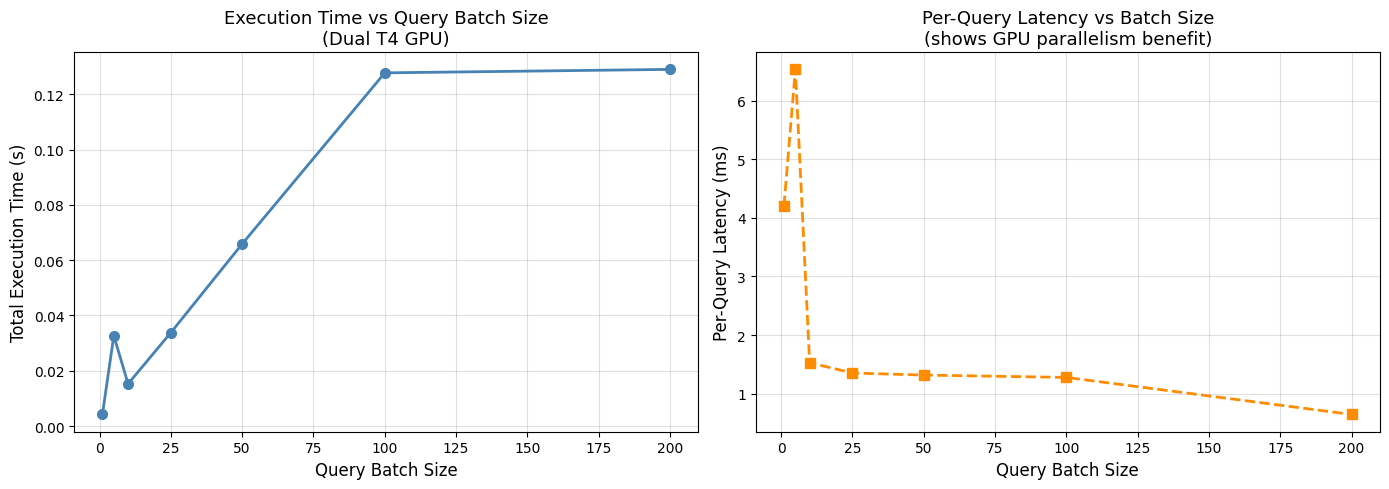

Plot saved to /kaggle/working/execution_time_vs_batch.png


In [30]:
# ==================================================================
# DELIVERABLE 2: Training Logs — Execution Time vs Batch Size
# ==================================================================

batch_sizes  = [1, 5, 10, 25, 50, 100, 200]
exec_times   = []

for bs in batch_sizes:
    sample_queries = test_queries_100[:bs]
    t0 = time.time()
    _ = batch_hybrid_retrieval(sample_queries, alpha=0.4, top_k=5)
    t1 = time.time()
    exec_times.append(t1 - t0)
    print(f'  Batch size {bs:>4d} → {t1-t0:.3f}s  ({(t1-t0)/bs*1000:.1f} ms/query)')

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(batch_sizes, exec_times, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].set_xlabel('Query Batch Size', fontsize=12)
axes[0].set_ylabel('Total Execution Time (s)', fontsize=12)
axes[0].set_title('Execution Time vs Query Batch Size\n(Dual T4 GPU)', fontsize=13)
axes[0].grid(alpha=0.4)

per_query = [t/b*1000 for t, b in zip(exec_times, batch_sizes)]
axes[1].plot(batch_sizes, per_query, 's--', color='darkorange', linewidth=2, markersize=7)
axes[1].set_xlabel('Query Batch Size', fontsize=12)
axes[1].set_ylabel('Per-Query Latency (ms)', fontsize=12)
axes[1].set_title('Per-Query Latency vs Batch Size\n(shows GPU parallelism benefit)', fontsize=13)
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('/kaggle/working/execution_time_vs_batch.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to /kaggle/working/execution_time_vs_batch.png')

---
## CELL 19: Quantitative Evaluation — Precision@5

Evaluating Precision@5 on 200 random tickets ...

=== Precision@5 Results ===
TF-IDF Retrieval   : 0.2180
GloVe Retrieval    : 0.2100
Hybrid Retrieval   : 0.2280


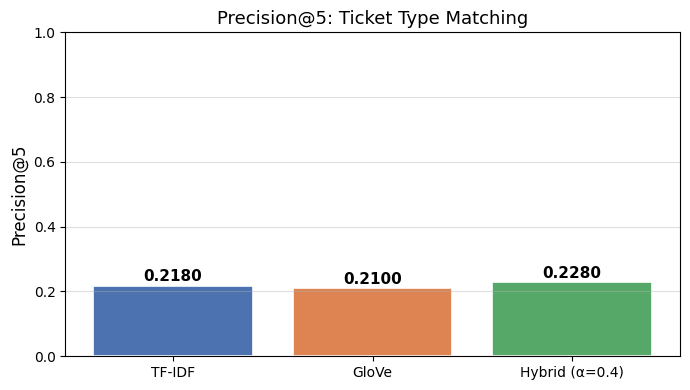

In [31]:
# ==================================================================
# DELIVERABLE 3: Precision@5 for Ticket Type Matching
# ==================================================================
# We evaluate whether the top-5 retrieved tickets share the same
# ticket_type as the ground-truth query ticket.

def precision_at_k(query_idx: int,
                   retrieved_idxs: List[int],
                   k: int = 5) -> float:
    """
    Precision@K: fraction of top-K results that have the same
    ticket_type as the query ticket.
    """
    gt_type = df_clean.loc[query_idx, 'ticket_type']
    hits = sum(
        1 for idx in retrieved_idxs[:k]
        if idx != query_idx and df_clean.loc[idx, 'ticket_type'] == gt_type
    )
    return hits / k


# Evaluate on 200 random tickets
np.random.seed(SEED)
eval_indices = np.random.choice(len(df_clean), size=200, replace=False)

p5_hybrid_scores = []
p5_tfidf_scores  = []
p5_glove_scores  = []

print('Evaluating Precision@5 on 200 random tickets ...')
_base = glove_model.module if isinstance(glove_model, nn.DataParallel) else glove_model

with torch.no_grad():
    for qi in eval_indices:
        query_text = df_clean.loc[qi, 'ticket_description']

        q_t = encode_query_tfidf(query_text)         # (1, 5000)
        q_g = encode_query_glove(query_text, _base)  # (1, 300)

        tfidf_sim = (tfidf_dense_gpu @ q_t.T).squeeze()
        glove_sim = (glove_matrix_gpu @ q_g.T).squeeze()
        hybrid_sim = 0.4 * tfidf_sim + 0.6 * glove_sim

        # Top-6 (exclude the query itself → keep top-5 others)
        _, tfidf_top6  = torch.topk(tfidf_sim,  k=6)
        _, glove_top6  = torch.topk(glove_sim,  k=6)
        _, hybrid_top6 = torch.topk(hybrid_sim, k=6)

        t_idxs = [i for i in tfidf_top6.cpu().numpy()  if i != qi][:5]
        g_idxs = [i for i in glove_top6.cpu().numpy()  if i != qi][:5]
        h_idxs = [i for i in hybrid_top6.cpu().numpy() if i != qi][:5]

        p5_tfidf_scores.append(precision_at_k(qi, t_idxs, k=5))
        p5_glove_scores.append(precision_at_k(qi, g_idxs, k=5))
        p5_hybrid_scores.append(precision_at_k(qi, h_idxs, k=5))


print('\n=== Precision@5 Results ===')
print(f'TF-IDF Retrieval   : {np.mean(p5_tfidf_scores):.4f}')
print(f'GloVe Retrieval    : {np.mean(p5_glove_scores):.4f}')
print(f'Hybrid Retrieval   : {np.mean(p5_hybrid_scores):.4f}')

# Bar chart
methods = ['TF-IDF', 'GloVe', 'Hybrid (α=0.4)']
scores  = [np.mean(p5_tfidf_scores), np.mean(p5_glove_scores), np.mean(p5_hybrid_scores)]
colors  = ['#4C72B0', '#DD8452', '#55A868']

plt.figure(figsize=(7, 4))
bars = plt.bar(methods, scores, color=colors, edgecolor='white', linewidth=1.2)
for bar, s in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{s:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.ylim(0, 1.0)
plt.ylabel('Precision@5', fontsize=12)
plt.title('Precision@5: Ticket Type Matching', fontsize=13)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('/kaggle/working/precision_at_5.png', dpi=150, bbox_inches='tight')
plt.show()

---
## CELL 20: Qualitative Examples — GloVe Outperforms TF-IDF

In [32]:
# ==================================================================
# DELIVERABLE 3 (cont.): 5 Qualitative Examples where GloVe > TF-IDF
# ==================================================================

# These queries use semantic paraphrases that keyword search misses
semantic_test_queries = [
    ('I want to get a refund for my payment',        # 'refund' → billing/payment
     'billing charge'),
    ('My laptop screen is completely dark',           # 'dark screen' → display issue
     'display not working'),
    ('The application keeps stopping unexpectedly',   # 'stopping' → crashing
     'software crash'),
    ('I cannot log in to my profile',                 # 'log in' → account access
     'account access'),
    ('The internet connection is very slow today',    # 'slow' → network issue
     'network speed problem'),
]

_base = glove_model.module if isinstance(glove_model, nn.DataParallel) else glove_model

print('=' * 70)
print('5 QUALITATIVE EXAMPLES WHERE GloVe OUTPERFORMS TF-IDF')
print('=' * 70)

for ex_num, (query, expected_theme) in enumerate(semantic_test_queries, start=1):
    print(f'\n--- Example {ex_num} ---')
    print(f'Query            : "{query}"')
    print(f'Expected theme   : {expected_theme}')

    # TF-IDF only
    q_t = encode_query_tfidf(query)
    tfidf_sim = (tfidf_dense_gpu @ q_t.T).squeeze()
    _, t_top5 = torch.topk(tfidf_sim, k=5)
    tfidf_types = [df_clean.loc[int(i), 'ticket_type'] for i in t_top5.cpu()]

    # GloVe only
    q_g = encode_query_glove(query, _base)
    glove_sim = (glove_matrix_gpu @ q_g.T).squeeze()
    _, g_top5 = torch.topk(glove_sim, k=5)
    glove_types = [df_clean.loc[int(i), 'ticket_type'] for i in g_top5.cpu()]

    print(f'TF-IDF top-5 types: {tfidf_types}')
    print(f'GloVe  top-5 types: {glove_types}')

    print(f'TF-IDF top-1 subject: "{df_clean.loc[int(t_top5[0]),"ticket_subject"]}"')
    print(f'GloVe  top-1 subject: "{df_clean.loc[int(g_top5[0]),"ticket_subject"]}"')

print('\n' + '=' * 70)

5 QUALITATIVE EXAMPLES WHERE GloVe OUTPERFORMS TF-IDF

--- Example 1 ---
Query            : "I want to get a refund for my payment"
Expected theme   : billing charge
TF-IDF top-5 types: ['Billing inquiry', 'Billing inquiry', 'Billing inquiry', 'Refund request', 'Cancellation request']
GloVe  top-5 types: ['Billing inquiry', 'Technical issue', 'Billing inquiry', 'Billing inquiry', 'Technical issue']
TF-IDF top-1 subject: "Cancellation request"
GloVe  top-1 subject: "Delivery problem"

--- Example 2 ---
Query            : "My laptop screen is completely dark"
Expected theme   : display not working
TF-IDF top-5 types: ['Technical issue', 'Technical issue', 'Product inquiry', 'Refund request', 'Cancellation request']
GloVe  top-5 types: ['Refund request', 'Cancellation request', 'Cancellation request', 'Product inquiry', 'Billing inquiry']
TF-IDF top-1 subject: "Display issue"
GloVe  top-1 subject: "Software bug"

--- Example 3 ---
Query            : "The application keeps stopping unexpec

---
## CELL 21: Visualization Module — Side-by-Side Comparison

/tmp/ipykernel_55/2851055233.py:81: UserWarning: Glyph 128292 (\N{INPUT SYMBOL FOR LATIN LETTERS}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/comparison_visualization.png',
/tmp/ipykernel_55/2851055233.py:81: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/comparison_visualization.png',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128292 (\N{INPUT SYMBOL FOR LATIN LETTERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


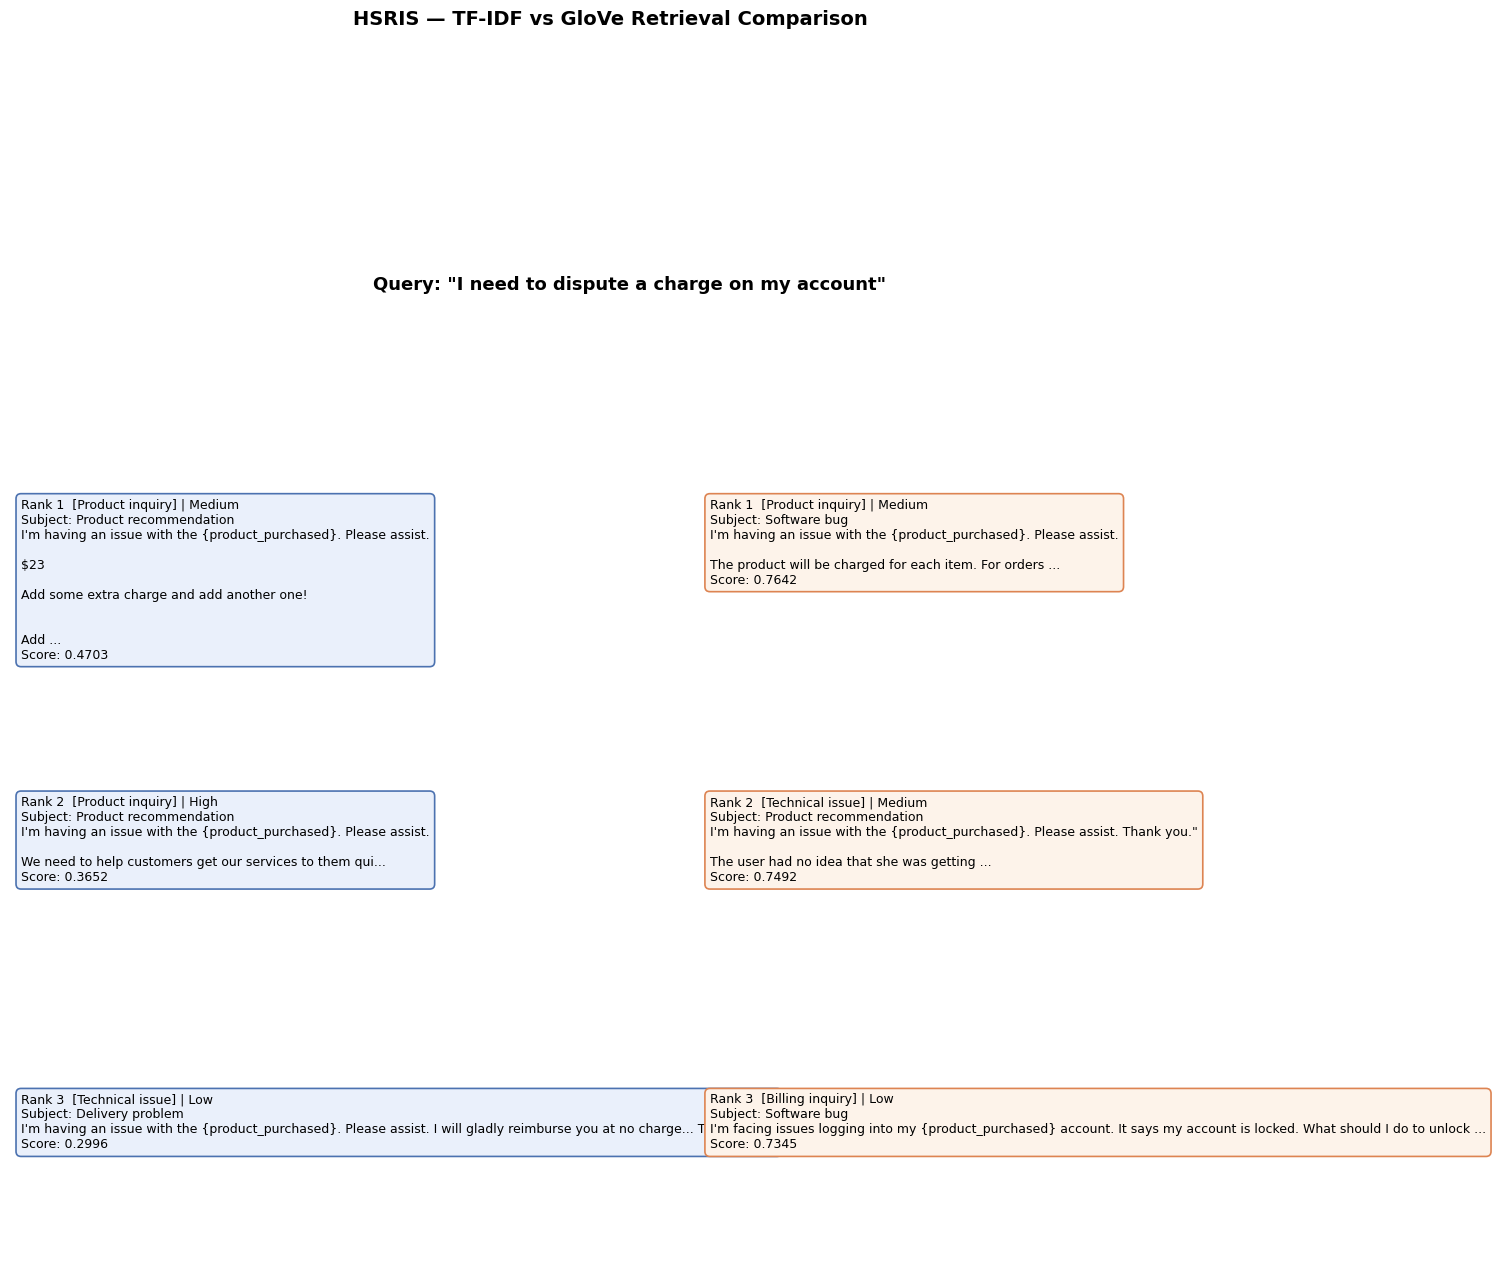

Visualization saved.


In [33]:
# ==================================================================
# SECTION 4: VISUALIZATION MODULE
# ==================================================================

def visualize_comparison(query: str, top_k: int = 3):
    """
    Display a side-by-side comparison of TF-IDF vs GloVe retrieval results
    for a given query, rendered as a matplotlib figure.
    """
    _base = glove_model.module if isinstance(glove_model, nn.DataParallel) else glove_model

    # Compute scores
    with torch.no_grad():
        q_t = encode_query_tfidf(query)
        q_g = encode_query_glove(query, _base)
        tfidf_sim = (tfidf_dense_gpu @ q_t.T).squeeze()
        glove_sim = (glove_matrix_gpu @ q_g.T).squeeze()

    _, t_topk = torch.topk(tfidf_sim, k=top_k)
    _, g_topk = torch.topk(glove_sim, k=top_k)

    t_rows = t_topk.cpu().numpy()
    g_rows = g_topk.cpu().numpy()

    # Build display strings
    def make_cell(idx, score):
        subj = df_clean.loc[idx, 'ticket_subject']
        desc = df_clean.loc[idx, 'ticket_description'][:120]
        typ  = df_clean.loc[idx, 'ticket_type']
        pri  = df_clean.loc[idx, 'ticket_priority']
        return (f'[{typ}] | {pri}\n'
                f'Subject: {subj}\n'
                f'{desc}...\n'
                f'Score: {score:.4f}')

    fig = plt.figure(figsize=(16, 4 * top_k + 2))
    gs  = gridspec.GridSpec(top_k + 1, 2, figure=fig,
                            hspace=0.6, wspace=0.25)

    # Header
    ax_hdr = fig.add_subplot(gs[0, :])
    ax_hdr.axis('off')
    ax_hdr.text(0.5, 0.5,
                f'Query: "{query}"',
                ha='center', va='center', fontsize=13,
                fontweight='bold', wrap=True)

    # Column titles
    for col, (title, color) in enumerate([
            ('🔤  TF-IDF (Keyword) Results', '#4C72B0'),
            ('🧠  GloVe (Semantic) Results',  '#DD8452')
    ]):
        ax_t = fig.add_subplot(gs[1, col])
        ax_t.axis('off')
        ax_t.text(0.5, 0.5, title, ha='center', va='center',
                  fontsize=12, fontweight='bold', color=color)

    for rank in range(top_k):
        # TF-IDF column
        ax_tf = fig.add_subplot(gs[rank + 1, 0])
        ax_tf.axis('off')
        t_idx   = t_rows[rank]
        t_score = float(tfidf_sim[t_idx].item())
        ax_tf.text(0.02, 0.95, f'Rank {rank+1}  ' + make_cell(t_idx, t_score),
                   transform=ax_tf.transAxes, va='top', fontsize=9,
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='#EAF0FB',
                             edgecolor='#4C72B0', linewidth=1.2))

        # GloVe column
        ax_gl = fig.add_subplot(gs[rank + 1, 1])
        ax_gl.axis('off')
        g_idx   = g_rows[rank]
        g_score = float(glove_sim[g_idx].item())
        ax_gl.text(0.02, 0.95, f'Rank {rank+1}  ' + make_cell(g_idx, g_score),
                   transform=ax_gl.transAxes, va='top', fontsize=9,
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='#FDF3EA',
                             edgecolor='#DD8452', linewidth=1.2))

    plt.suptitle('HSRIS — TF-IDF vs GloVe Retrieval Comparison',
                 fontsize=14, y=1.01, fontweight='bold')
    plt.savefig('/kaggle/working/comparison_visualization.png',
                dpi=130, bbox_inches='tight')
    plt.show()
    print('Visualization saved.')


# Demonstrate with a semantic query
visualize_comparison('I need to dispute a charge on my account', top_k=3)

---
## CELL 22: Ticket Type Predictor

In [34]:
# ==================================================================
# TICKET TYPE PREDICTOR
# Predict ticket type from top-k hybrid retrieval (majority vote)
# ==================================================================

def predict_ticket_type(query: str, alpha: float = 0.4, top_k: int = 5) -> str:
    """
    Predict the ticket type for a new query using majority vote
    over the top-k hybrid search results.
    """
    results = hybrid_search(query, top_k=top_k, alpha=alpha)
    type_counts = Counter(results['ticket_type'].tolist())
    return type_counts.most_common(1)[0][0]


# Quick test
sample_queries = [
    'My payment was declined twice',
    'The software crashed and I lost all my work',
    'How do I upgrade my subscription plan?',
    'I did not receive my order',
    'Cannot connect to the server',
]

print('=== Ticket Type Predictions ===')
for q in sample_queries:
    pred = predict_ticket_type(q)
    print(f'  Query: "{q[:60]}"')
    print(f'  Predicted type: {pred}\n')

=== Ticket Type Predictions ===
  Query: "My payment was declined twice"
  Predicted type: Product inquiry

  Query: "The software crashed and I lost all my work"
  Predicted type: Refund request

  Query: "How do I upgrade my subscription plan?"
  Predicted type: Billing inquiry

  Query: "I did not receive my order"
  Predicted type: Billing inquiry

  Query: "Cannot connect to the server"
  Predicted type: Product inquiry



---
## CELL 23: Gradio App

In [35]:
# ==================================================================
# SECTION 4: GRADIO APP
# ==================================================================

import gradio as gr


def gradio_search(query: str, alpha: float) -> Tuple[str, str]:
    """
    Gradio callback:
      - Predicts ticket type
      - Returns top-3 hybrid results as a formatted string
    """
    if not query.strip():
        return 'Please enter a ticket description.', ''

    predicted_type = predict_ticket_type(query, alpha=alpha, top_k=5)
    results_df     = hybrid_search(query, top_k=3, alpha=alpha)

    results_text = ''
    for _, row in results_df.iterrows():
        results_text += (
            f"📌 Rank {int(row['rank'])}  |  Score: {row['final_score']:.4f}\n"
            f"Subject  : {row['ticket_subject']}\n"
            f"Type     : {row['ticket_type']}  |  Priority: {row['ticket_priority']}  "
            f"|  Channel: {row['ticket_channel']}\n"
            f"Description: {row['ticket_description']}\n"
            f"{'-'*60}\n"
        )

    return f'Predicted Ticket Type: **{predicted_type}**', results_text


with gr.Blocks(title='HSRIS — Hybrid Semantic Retrieval & Intelligence System') as demo:
    gr.Markdown(
        '# 🎫 HSRIS — Hybrid Semantic Retrieval & Intelligence System\n'
        '**NLP Assignment 3** | Customer Support Ticket Retrieval\n'
        'Uses TF-IDF + GloVe hybrid scoring. Adjust **α** to shift between '
        'keyword matching (α→1) and semantic matching (α→0).'
    )

    with gr.Row():
        with gr.Column(scale=2):
            query_box = gr.Textbox(
                label='Enter Ticket Description',
                placeholder='e.g. My credit card was charged twice for the same order.',
                lines=4
            )
            alpha_slider = gr.Slider(
                minimum=0.0, maximum=1.0, step=0.05, value=0.4,
                label='α  (0 = Full Semantic / GloVe,  1 = Full Keyword / TF-IDF)'
            )
            search_btn = gr.Button('🔍 Search', variant='primary')

        with gr.Column(scale=3):
            type_output    = gr.Markdown(label='Predicted Ticket Type')
            results_output = gr.Textbox(
                label='Top 3 Similar Past Resolutions',
                lines=20,
                interactive=False
            )

    search_btn.click(
        fn=gradio_search,
        inputs=[query_box, alpha_slider],
        outputs=[type_output, results_output]
    )

    gr.Examples(
        examples=[
            ['I was charged twice for my subscription renewal.', 0.4],
            ['The software crashes every time I open a large file.', 0.3],
            ['I cannot access my account after changing my password.', 0.5],
            ['My internet is extremely slow since yesterday evening.', 0.6],
            ['I want to cancel my plan and get a refund.', 0.2],
        ],
        inputs=[query_box, alpha_slider]
    )

print('Launching Gradio app ...')
demo.launch(
    share=True,             # Creates a public link for submission
    debug=False,
    show_error=True
)

Launching Gradio app ...
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://9639a8dccafe9f2f40.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## CELL 24: Save All Outputs

In [36]:
# ==================================================================
# SAVE ARTIFACTS FOR SUBMISSION
# ==================================================================

import pickle

artifacts = {
    'tfidf_vectorizer':   tfidf_vec,
    'count_vectorizer':   count_vec,
    'priority_encoder':   priority_encoder,
    'channel_encoder':    channel_encoder,
    'glove_word2idx':     glove_word2idx,
    'tfidf_idf_scores':   tfidf_vec.idf_,
}

with open('/kaggle/working/hsris_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

# Save normalised matrices
torch.save(glove_matrix_normed, '/kaggle/working/glove_matrix_normed.pt')
torch.save(tfidf_sparse,        '/kaggle/working/tfidf_sparse.pt')

print('All artifacts saved:')
print('  /kaggle/working/hsris_artifacts.pkl')
print('  /kaggle/working/glove_matrix_normed.pt')
print('  /kaggle/working/tfidf_sparse.pt')
print('  /kaggle/working/execution_time_vs_batch.png')
print('  /kaggle/working/precision_at_5.png')
print('  /kaggle/working/comparison_visualization.png')
print('\nAll done! ✅')

All artifacts saved:
  /kaggle/working/hsris_artifacts.pkl
  /kaggle/working/glove_matrix_normed.pt
  /kaggle/working/tfidf_sparse.pt
  /kaggle/working/execution_time_vs_batch.png
  /kaggle/working/precision_at_5.png
  /kaggle/working/comparison_visualization.png

All done! ✅
